In [13]:
import pandapower as pp
import pandapower.networks as pn
import pandapower.plotting as plot
import pandapower.plotting.geo as pgeo
import pandas as pd
import networkx as nx

import matplotlib.pyplot as plt

In [3]:
# Load the standard IEEE 33-bus distribution system (Passive Grid)
net = pn.case33bw()

In [ ]:
# A. Add Distributed Generation (DG) Units
# The paper places 0.2 MW dispatchable units at specific buses.
# Note: Paper buses 18, 22, 25, 33 -> Python indices 17, 21, 24, 32
dg_buses = [17, 21, 24, 32]
for bus in dg_buses:
    pp.create_sgen(net, bus=bus, p_mw=0.2, q_mvar=0, name=f"DG_Bus_{bus+1}")

In [4]:
# B. Add Reactive Power Compensators (RPCs)
# The paper adds capacitive RPCs for radial configuration voltage control.
# Note: Paper bus 18 (0.4 MVAR) -> Python index 17
# Note: Paper bus 33 (0.6 MVAR) -> Python index 32
pp.create_shunt(net, bus=17, q_mvar=-0.4, name="RPC_Bus_18")
pp.create_shunt(net, bus=32, q_mvar=-0.6, name="RPC_Bus_33")

np.int64(1)

In [5]:
net

This pandapower network includes the following parameter tables:
   - bus (33 elements)
   - load (32 elements)
   - shunt (2 elements)
   - ext_grid (1 element)
   - line (37 elements)
   - poly_cost (1 element)

In [6]:
# C. Add Switchable Tie-Lines (For Meshed / Reconfiguration Studies)
# The paper adds three switchable branches.
# Branch 33: Bus 21 to 8 -> Indices 20 to 7 (R: 2.0, X: 2.0)
# Branch 34: Bus 12 to 22 -> Indices 11 to 21 (R: 2.0, X: 2.0)
# Branch 35: Bus 25 to 29 -> Indices 24 to 28 (R: 0.5, X: 0.5)
# We initialize them as "out of service" (in_service=False) for the default radial mode.
pp.create_line_from_parameters(net, from_bus=20, to_bus=7, length_km=1, 
                               r_ohm_per_km=2.0, x_ohm_per_km=2.0, c_nf_per_km=0, 
                               max_i_ka=1, name="TieLine_33", in_service=False)

pp.create_line_from_parameters(net, from_bus=11, to_bus=21, length_km=1, 
                               r_ohm_per_km=2.0, x_ohm_per_km=2.0, c_nf_per_km=0, 
                               max_i_ka=1, name="TieLine_34", in_service=False)

pp.create_line_from_parameters(net, from_bus=24, to_bus=28, length_km=1, 
                               r_ohm_per_km=0.5, x_ohm_per_km=0.5, c_nf_per_km=0, 
                               max_i_ka=1, name="TieLine_35", in_service=False)

np.int64(39)

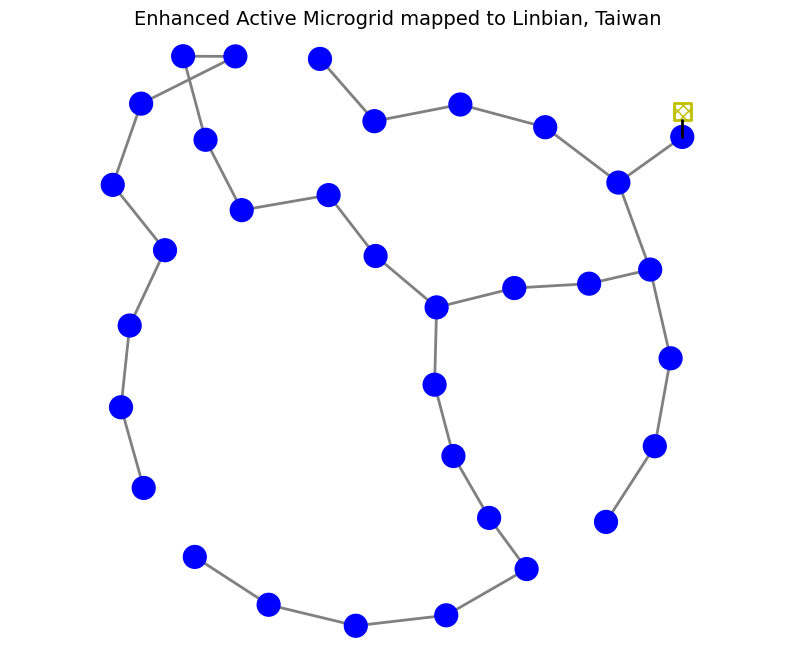


Power Flow Converged!
Total Load (Active): 3.71 MW
Total DG Generation: 0.00 MW
Total Reactive Power Compensation: -0.88 MVAR


In [14]:
# Manually initialize the missing geographic dataframe
net.bus_geodata = pd.DataFrame(columns=['x', 'y'], index=net.bus.index)

# Read the grid's lines and build a map using networkx
G = nx.Graph()
G.add_edges_from(net.line[['from_bus', 'to_bus']].values)

# Calculate a radial graph layout (Kamada-Kawai algorithm)
pos = nx.kamada_kawai_layout(G)

# Save those abstract coordinates into pandapower's geodata table
for bus_id, coords in pos.items():
    net.bus_geodata.loc[bus_id, 'x'] = coords[0]
    net.bus_geodata.loc[bus_id, 'y'] = coords[1]

# Scale and shift the coordinates to Linbian, Taiwan
base_lat, base_lng = 22.434, 120.516

x_min, x_max = net.bus_geodata.x.min(), net.bus_geodata.x.max()
y_min, y_max = net.bus_geodata.y.min(), net.bus_geodata.y.max()

x_range = x_max - x_min if x_max != x_min else 1
y_range = y_max - y_min if y_max != y_min else 1

net.bus_geodata.x = base_lng + ((net.bus_geodata.x - x_min) / x_range - 0.5) * 0.045
net.bus_geodata.y = base_lat + ((net.bus_geodata.y - y_min) / y_range - 0.5) * 0.045

pgeo.convert_geodata_to_geojson(net)
# Map the lines to the new bus coordinates for future plotting
fig, ax = plt.subplots(figsize=(10, 8))
plot.simple_plot(net, ax=ax, show_plot=False, bus_size=2.0, line_width=2.0)
ax.set_title("Enhanced Active Microgrid mapped to Linbian, Taiwan", fontsize=14)
plt.show()

# ==============================================================================
# 5. RUN POWER FLOW TEST
# ==============================================================================
try:
    pp.runpp(net)
    print("\nPower Flow Converged!")
    print(f"Total Load (Active): {net.res_load.p_mw.sum():.2f} MW")
    print(f"Total DG Generation: {net.res_sgen.p_mw.sum():.2f} MW")
    
    # Let's also check if our Shunts (RPCs) are working!
    print(f"Total Reactive Power Compensation: {net.res_shunt.q_mvar.sum():.2f} MVAR")
except pp.pandapower.LoadflowNotConverged:
    print("Power Flow failed to converge.")

The supplied network uses an outdated geodata format. Please update your geodata by
running `pandapower.plotting.geo.convert_geodata_to_geojson(net)`


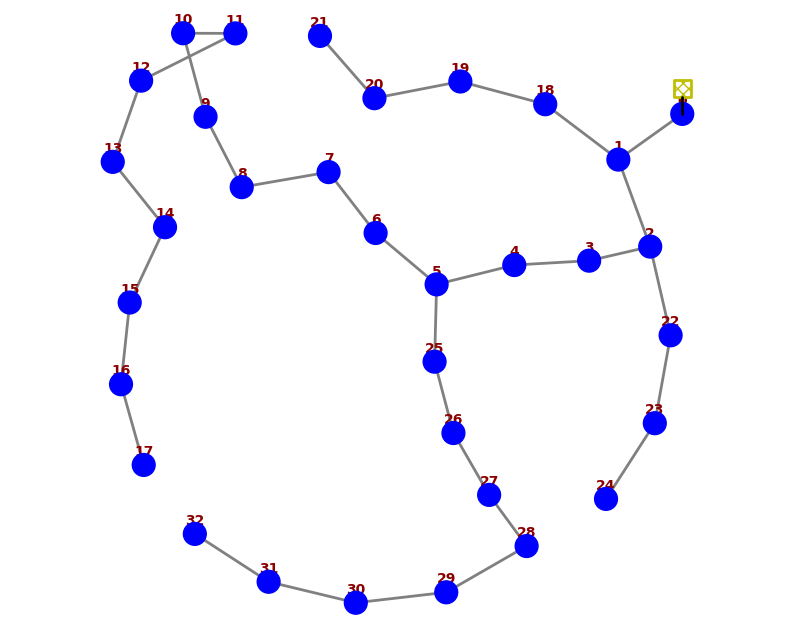


Power Flow Converged!
Total Load (Active): 3.71 MW
Total DG Generation: 0.00 MW
Total Reactive Power Compensation: -0.88 MVAR


In [18]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import pandapower.plotting as plot

# Manually initialize the missing geographic dataframe
net.bus_geodata = pd.DataFrame(columns=['x', 'y'], index=net.bus.index)

# Read the grid's lines and build a map using networkx
G = nx.Graph()
G.add_edges_from(net.line[['from_bus', 'to_bus']].values)

# Calculate a radial graph layout (Kamada-Kawai algorithm)
pos = nx.kamada_kawai_layout(G)

# Save those abstract coordinates into pandapower's geodata table
for bus_id, coords in pos.items():
    net.bus_geodata.loc[bus_id, 'x'] = coords[0]
    net.bus_geodata.loc[bus_id, 'y'] = coords[1]

# Scale and shift the coordinates to Linbian, Taiwan
base_lat, base_lng = 22.434, 120.516

x_min, x_max = net.bus_geodata.x.min(), net.bus_geodata.x.max()
y_min, y_max = net.bus_geodata.y.min(), net.bus_geodata.y.max()

x_range = x_max - x_min if x_max != x_min else 1
y_range = y_max - y_min if y_max != y_min else 1

net.bus_geodata.x = base_lng + ((net.bus_geodata.x - x_min) / x_range - 0.5) * 0.045
net.bus_geodata.y = base_lat + ((net.bus_geodata.y - y_min) / y_range - 0.5) * 0.045

# MUST REMOVE/COMMENT OUT so we don't delete the geodata needed for the numbers below
# pgeo.convert_geodata_to_geojson(net) 

# Map the lines to the new bus coordinates for future plotting
fig, ax = plt.subplots(figsize=(10, 8))
plot.simple_plot(net, ax=ax, show_plot=False, bus_size=2.0, line_width=2.0)

# ---> ADD THE BUS NUMBERS <---
for bus_id in net.bus_geodata.index:
    x = net.bus_geodata.loc[bus_id, 'x']
    y = net.bus_geodata.loc[bus_id, 'y']
    # y + 0.0007 shifts the text slightly above the bus dot
    ax.text(x, y + 0.0007, str(bus_id), color='darkred', fontsize=10, fontweight='bold', ha='center', zorder=3)

# ax.set_title("Enhanced Active Microgrid mapped to Linbian, Taiwan", fontsize=14)
plt.show()

# ==============================================================================
# 5. RUN POWER FLOW TEST
# ==============================================================================
try:
    pp.runpp(net)
    print("\nPower Flow Converged!")
    print(f"Total Load (Active): {net.res_load.p_mw.sum():.2f} MW")
    print(f"Total DG Generation: {net.res_sgen.p_mw.sum():.2f} MW")
    
    # Let's also check if our Shunts (RPCs) are working!
    print(f"Total Reactive Power Compensation: {net.res_shunt.q_mvar.sum():.2f} MVAR")
except pp.pandapower.LoadflowNotConverged:
    print("Power Flow failed to converge.")